In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df = pd.read_csv("../data/raw/study_records.csv")
df.head()

,student_id,topic,exam_frequency,question_marks,difficulty,knowledge_before,study_minutes,quiz_before,quiz_after,exam_score
0,S001,TCP Congestion Control,9,10,8,25,90,30,82,86
1,S001,HTTP,8,8,6,40,60,45,88,91
2,S001,DNS,5,5,4,65,35,68,91,89
3,S001,Routing,8,8,7,30,60,35,78,84
4,S001,UDP,3,5,3,80,25,82,94,92


In [5]:
df.shape

(25, 10)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   student_id        25 non-null     str  
 1   topic             25 non-null     str  
 2   exam_frequency    25 non-null     int64
 3   question_marks    25 non-null     int64
 4   difficulty        25 non-null     int64
 5   knowledge_before  25 non-null     int64
 6   study_minutes     25 non-null     int64
 7   quiz_before       25 non-null     int64
 8   quiz_after        25 non-null     int64
 9   exam_score        25 non-null     int64
dtypes: int64(8), str(2)
memory usage: 2.1 KB


In [9]:
df["learning_gain"] = (
    df["quiz_after"] - df["quiz_before"]
)

In [10]:
df[["quiz_before", "quiz_after", "learning_gain"]].head()

,quiz_before,quiz_after,learning_gain
0,30,82,52
1,45,88,43
2,68,91,23
3,35,78,43
4,82,94,12


In [11]:
features = [
    "exam_frequency",
    "question_marks",
    "difficulty",
    "knowledge_before",
    "study_minutes",
    "quiz_before"
]

X = df[features]
y = df["learning_gain"]

In [13]:
X.head()

,exam_frequency,question_marks,difficulty,knowledge_before,study_minutes,quiz_before
0,9,10,8,25,90,30
1,8,8,6,40,60,45
2,5,5,4,65,35,68
3,8,8,7,30,60,35
4,3,5,3,80,25,82


In [14]:
y.head()

0    52
1    43
2    23
3    43
4    12
Name: learning_gain, dtype: int64

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
print("Training samples", len(X_train))
print("Tesing samples", len(X_test))

Training samples 20
Tesing samples 5


In [19]:
model = LinearRegression()

In [20]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 1.96, 1.26,-3.64, 0.02, 0.14,-0.59]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['exam_frequency','question_marks','difficulty','knowledge_before', 'study_minutes','quiz_before']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,55.13
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [21]:
y_pred = model.predict(X_test)

In [22]:
y_pred

array([41.10263865, 48.27024437, 51.79887306, 52.38310795, 30.63528113])

In [24]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
results

,Actual,Predicted
0,40,41.102639
1,47,48.270244
2,52,51.798873
3,52,52.383108
4,30,30.635281


In [25]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.7184798089487302


In [26]:
mse = mean_absolute_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.7184798089487302


In [27]:
rmse = np.sqrt(mse)
print("RMSE", rmse)

RMSE 0.8476318829236723


In [28]:
r2 = r2_score(y_test,y_pred)
print("R²:", r2)

R²: 0.990194556717704


In [29]:
print("Model Evaluation")
print("-----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation
-----------------
MAE : 0.7184798089487302
MSE : 0.7184798089487302
RMSE: 0.8476318829236723
R²  : 0.990194556717704


<function matplotlib.pyplot.show(close=None, block=None)>

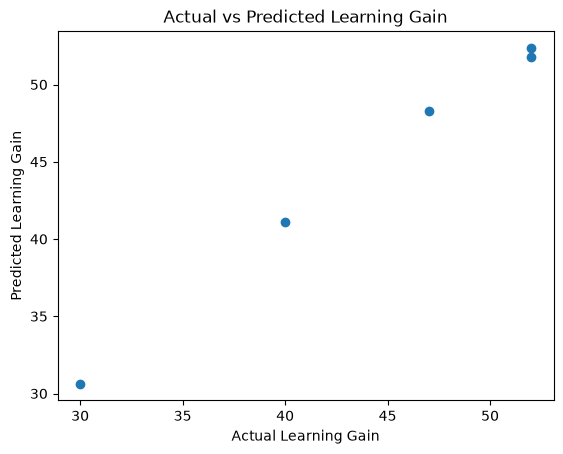

In [31]:
plt.Figure(figsize=(7,5))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Learning Gain")
plt.ylabel("Predicted Learning Gain")
plt.title("Actual vs Predicted Learning Gain")
plt.show

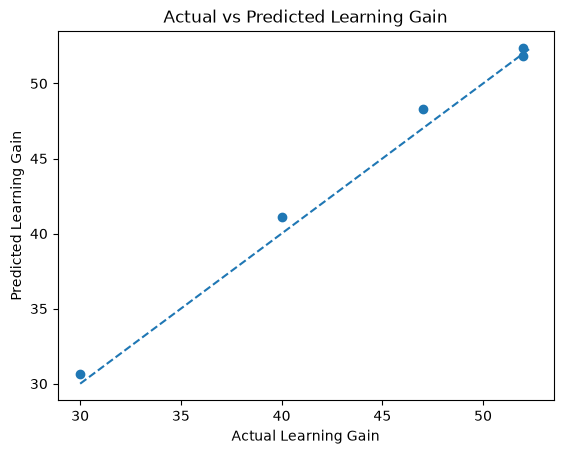

In [32]:
plt.Figure(figsize=(7,5))
plt.scatter(y_test,y_pred)
min_value= min(y_test.min(), y_pred.min())
max_value= max(y_test.max(), y_pred.max())
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual Learning Gain")
plt.ylabel("Predicted Learning Gain")
plt.title("Actual vs Predicted Learning Gain")
plt.show()

In [33]:
model.coef_

array([ 1.96098145,  1.26195765, -3.64061308,  0.01961878,  0.13989827,
       -0.58511904])

In [34]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})
coefficients

,Feature,Coefficient
0,exam_frequency,1.960981
1,question_marks,1.261958
2,difficulty,-3.640613
3,knowledge_before,0.019619
4,study_minutes,0.139898
5,quiz_before,-0.585119


In [35]:
features_without_time = [
    "exam_frequency",
    "question_marks",
    "difficulty",
    "knowledge_before",
    "quiz_before"
]

In [36]:
X2 = df[features_without_time]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42
)

model2 = LinearRegression()

model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)

In [37]:
mae2 = mean_absolute_error(y2_test, y2_pred)
r2_2 = r2_score(y2_test, y2_pred)

print("Without study time")
print("MAE:", mae2)
print("R²:", r2_2)

Without study time
MAE: 1.342455784506636
R²: 0.9650453498203849


In [38]:
new_student = pd.DataFrame({
    "exam_frequency": [9],
    "question_marks": [10],
    "difficulty": [8],
    "knowledge_before": [20],
    "study_minutes": [60],
    "quiz_before": [25]
})

In [39]:
predicted_gain = model.predict(new_student)
print("Predicted Learning Gain", predicted_gain[0])

Predicted Learning Gain 50.429426189117734


In [40]:
from sklearn.tree import DecisionTreeRegressor

In [41]:
tree_model = DecisionTreeRegressor(
    random_state = 42
)

In [42]:
tree_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [43]:
tree_pred = tree_model.predict(X_test)

In [44]:
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_r2 = r2_score(y_test, tree_pred)
print("Decition Tree MAE:", tree_mae)
print("Decision Tree R²:", tree_r2)

Decition Tree MAE: 3.2
Decision Tree R²: 0.8451834862385321


In [45]:
from sklearn.ensemble import RandomForestRegressor

In [46]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [47]:
rf_model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [48]:
rf_pred = rf_model.predict(X_test)

In [50]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 1.8079999999999998
Random Forest R²: 0.9399271788990826


In [51]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        tree_mae,
        rf_mae
    ],
    "R2": [
        r2,
        tree_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,R2
0,Linear Regression,0.71848,0.990195
1,Decision Tree,3.20000,0.845183
2,Random Forest,1.80800,0.939927


## My Day 3 Observations

1. My Linear Regression model achieved ...
2. Decision Tree achieved ...
3. Random Forest achieved ...
4. The most important feature seemed to be ...
5. I noticed that ...
6. I think the biggest limitation of my current model is ...